### **House Price Prediction**


### **Problem Statement**

The real estate industry often needs accurate estimation of property prices based on various
house characteristics. In this task, the goal is to build a Machine Learning regression model
that predicts the price of a house using features such as house size, number of bedrooms,
number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was
built.
Students are required to analyze the dataset, perform data preprocessing, apply feature
engineering techniques, train multiple regression models, and evaluate their performance to
identify the best model for predicting house prices.

### **Objective**

The objective of this task is to:
* Understand and explore the housing dataset.
* Perform data preprocessing including handling missing values, duplicates, and outliers.
* Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the
data.
* Apply encoding, log transformation, and feature scaling where necessary.
* Train multiple regression algorithms to predict house prices.
* Evaluate and compare model performance using appropriate evaluation metrics.

### **1. Import Librarary**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **2. Load Dataset**

In [2]:
data=pd.read_csv('house_price_regression_dataset.csv')
data

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06
...,...,...,...,...,...,...,...,...
995,3261,4,1,1978,2.165110,2,10,7.014940e+05
996,3179,1,2,1999,2.977123,1,10,6.837232e+05
997,2606,4,2,1962,4.055067,0,2,5.720240e+05
998,4723,5,2,1950,1.930921,0,7,9.648653e+05


### **3. Basic Checks**

In [3]:
data.shape

(1000, 8)

In [4]:
data.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


In [5]:
data.tail()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
995,3261,4,1,1978,2.165110,2,10,701493.997069
996,3179,1,2,1999,2.977123,1,10,683723.160704
997,2606,4,2,1962,4.055067,0,2,572024.023634
998,4723,5,2,1950,1.930921,0,7,964865.298639
999,3268,4,2,1983,3.108790,2,2,742599.253332


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


In [7]:
data.describe()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03
mean,2815.422000,2.990000,1.973000,1986.550000,2.778087,1.022000,5.615000,6.188610e+05
std,1255.514921,1.427564,0.820332,20.632916,1.297903,0.814973,2.887059,2.535681e+05
min,503.000000,1.000000,1.000000,1950.000000,0.506058,0.000000,1.000000,1.116269e+05
25%,1749.500000,2.000000,1.000000,1969.000000,1.665946,0.000000,3.000000,4.016482e+05
50%,2862.500000,3.000000,2.000000,1986.000000,2.809740,1.000000,6.000000,6.282673e+05
75%,3849.500000,4.000000,3.000000,2004.250000,3.923317,2.000000,8.000000,8.271413e+05
max,4999.000000,5.000000,3.000000,2022.000000,4.989303,2.000000,10.000000,1.108237e+06


In [8]:
data.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality', 'House_Price'],
      dtype='object')

In [9]:
data.dtypes

,0
Square_Footage,int64
Num_Bedrooms,int64
Num_Bathrooms,int64
Year_Built,int64
Lot_Size,float64
Garage_Size,int64
Neighborhood_Quality,int64
House_Price,float64


### **4. Handle Missing Values**

In [10]:
data.isnull().sum()

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


In [11]:
data.duplicated().sum()

np.int64(0)

### **5. Remove Duplicates**

In [14]:
print("Duplicate rows:", data.duplicated().sum())

Duplicate rows: 0


### **6. Perform Univariate Analysis**

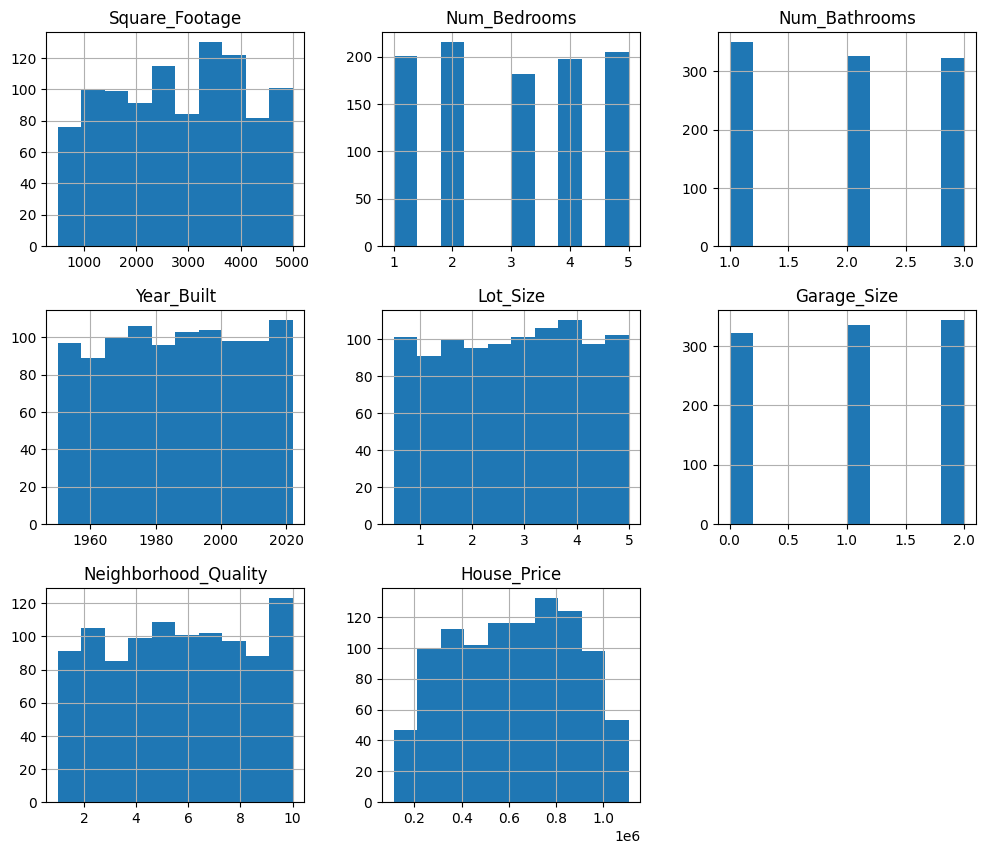

In [15]:
data.hist(figsize=(12,10))
plt.show()

### **7. Perform Bivariate Analysis**

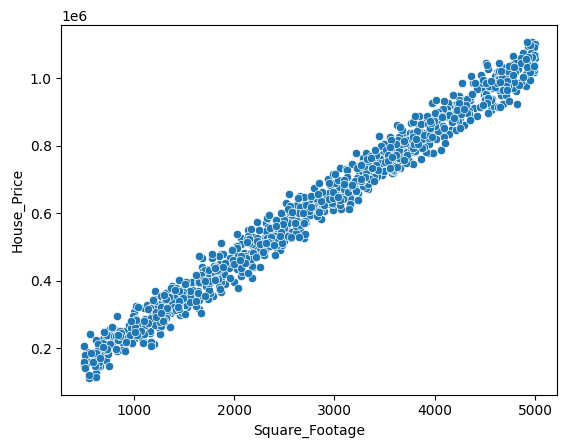

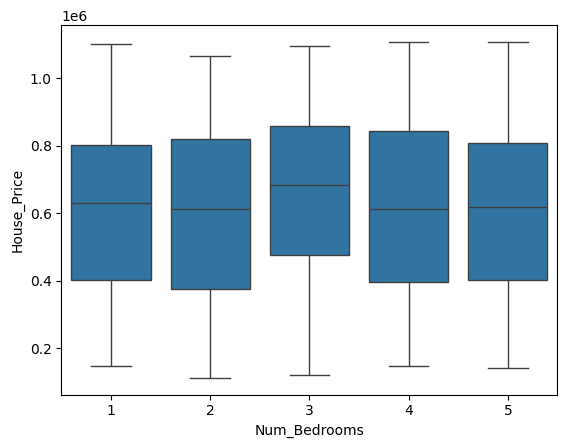

In [16]:
sns.scatterplot(data=data, x='Square_Footage', y='House_Price')
plt.show()

sns.boxplot(data=data, x='Num_Bedrooms', y='House_Price')
plt.show()

### **8. Generate Correlation Heatmap**

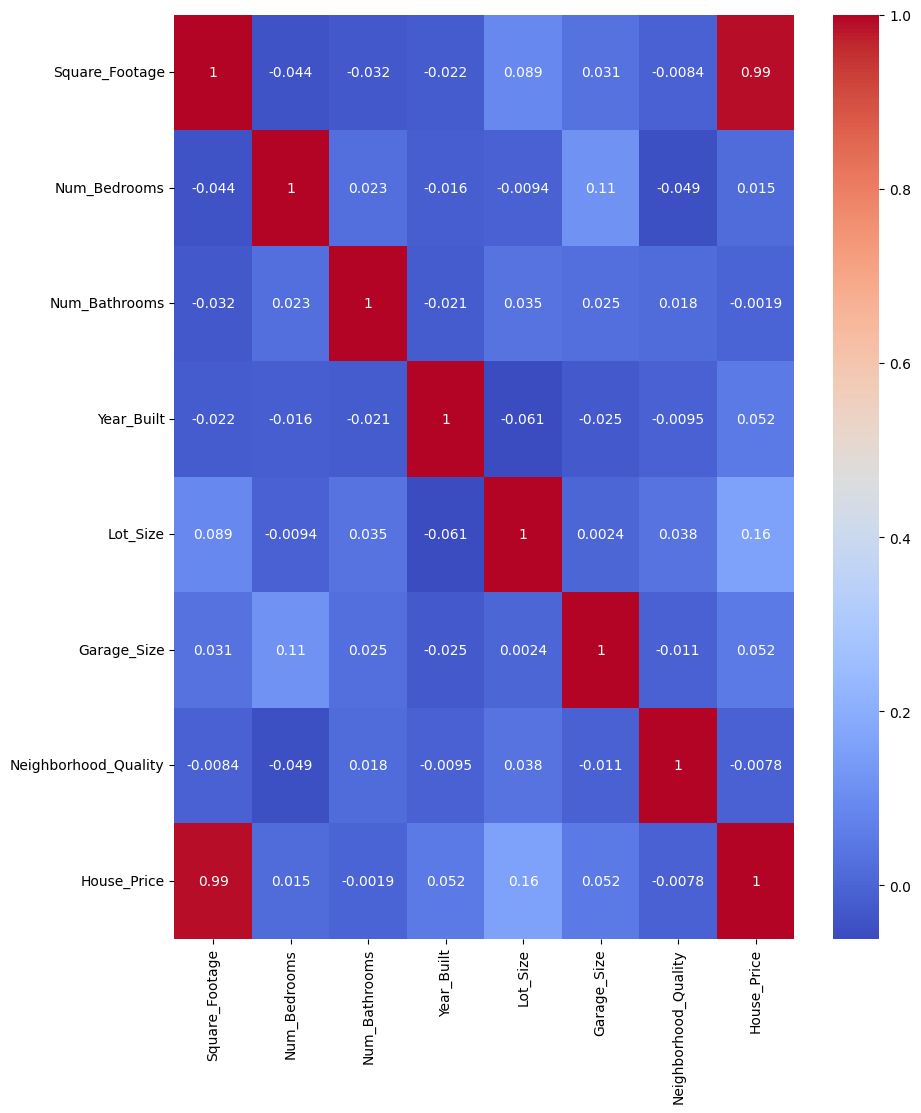

In [17]:
plt.figure(figsize=(10,12))
sns.heatmap(data.corr(),annot=True,cmap='coolwarm')
plt.show()

### **9.Detect and handle outliers**


In [18]:
for col in data.select_dtypes(include='number'):
  Q1 = data[col].quantile(0.25)
  Q3 = data[col].quantile(0.75)
  IQR = Q3 - Q1
  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR
  outliers = data[(data[col] < lower) | (data[col] > upper)]
  print(f"{col}: {len(outliers)} outliers")

Square_Footage: 0 outliers
Num_Bedrooms: 0 outliers
Num_Bathrooms: 0 outliers
Year_Built: 0 outliers
Lot_Size: 0 outliers
Garage_Size: 0 outliers
Neighborhood_Quality: 0 outliers
House_Price: 0 outliers


### **10. Apply Encoding**

In [26]:
categorical_cols = data.select_dtypes(include='object').columns
print(categorical_cols)

Index([], dtype='object')


In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in data.select_dtypes(include='object'):
  data[col]=le.fit_transform(data[col])

### **11. Apply Log Transformation**

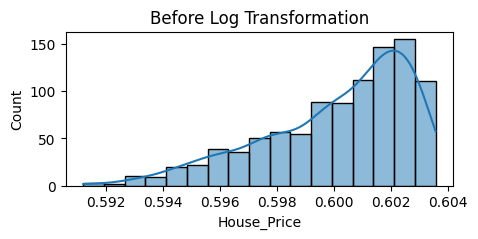

In [41]:
# Before Log Transformation
plt.figure(figsize=(5,2))
sns.histplot(data, x='House_Price', kde=True)
plt.title("Before Log Transformation")
plt.show()

In [39]:
# Applying Log Transformation
data['House_Price'] = np.log1p(data['House_Price'])

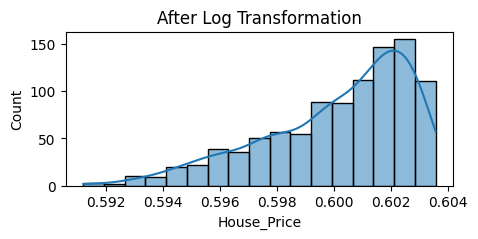

In [42]:
#After Applying Log Transformation
plt.figure(figsize=(5,2))
sns.histplot(data, x='House_Price', kde=True)
plt.title("After Log Transformation")
plt.show()

### **12. Separate Features and Target Variable**

In [45]:
X = data.drop('House_Price', axis=1)
y = data['House_Price']

### **13. Perform Train-Test-Split**

In [47]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### **14. Apply Feature Scaling**

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(x_train)
X_test = scaler.transform(x_test)

### **15. Train Regression Models**

In [50]:
# Linear Regression
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [52]:
# KNN Regression
from sklearn.neighbors import KNeighborsRegressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

### **16. Evaluate Models Using**

* MAE (Mean Absolute Error)

In [54]:
from sklearn.metrics import mean_absolute_error
mae_lr = mean_absolute_error(y_test, y_pred_lr)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
print("MAE - Linear Regression:", mae_lr)
print("MAE - KNN Regression:", mae_knn)

MAE - Linear Regression: 0.0005259836910615884
MAE - KNN Regression: 0.0006954715271175632


* MSE (Mean Squared Error)

In [55]:
from sklearn.metrics import mean_squared_error
mse_lr = mean_squared_error(y_test, y_pred_lr)
mse_knn = mean_squared_error(y_test, y_pred_knn)
print("MSE - Linear Regression:", mse_lr)
print("MSE - KNN Regression:", mse_knn)

MSE - Linear Regression: 4.368926371867485e-07
MSE - KNN Regression: 9.369374776852209e-07


* RMSE (Root Mean Squared Error)

In [56]:
rmse_lr = np.sqrt(mse_lr)
rmse_knn = np.sqrt(mse_knn)
print("RMSE - Linear Regression:", rmse_lr)
print("RMSE - KNN Regression:", rmse_knn)

RMSE - Linear Regression: 0.0006609785451788495
RMSE - KNN Regression: 0.0009679553076899888


* MAPE (Mean Absolute Percentage Error)

In [57]:
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100
mape_knn = np.mean(np.abs((y_test - y_pred_knn) / y_test)) * 100

print("MAPE - Linear Regression:", mape_lr)
print("MAPE - KNN Regression:", mape_knn)

MAPE - Linear Regression: 0.08777827708080943
MAPE - KNN Regression: 0.11618837877841313


* R2 Score

In [58]:
from sklearn.metrics import r2_score
r2_lr = r2_score(y_test, y_pred_lr)
r2_knn = r2_score(y_test, y_pred_knn)
print("R2 - Linear Regression:", r2_lr)
print("R2 - KNN Regression:", r2_knn)

R2 - Linear Regression: 0.9329228391294322
R2 - KNN Regression: 0.8561497709802515


* Adjusted R2 Score

In [60]:
n = len(y_test)
p = X_test.shape[1]
adj_r2_lr = 1 - (1 - r2_lr) * (n - 1) / (n - p - 1)
adj_r2_knn = 1 - (1 - r2_knn) * (n - 1) / (n - p - 1)
print("Adjusted R2 - Linear Regression:", adj_r2_lr)
print("Adjusted R2 - KNN Regression:", adj_r2_knn)

Adjusted R2 - Linear Regression: 0.9304773176393594
Adjusted R2 - KNN Regression: 0.8509052313805732
